# Internet research 

## Scope

https://www.siglent.eu/product/13555727/siglent-sds814x-hd-4ch-100mhz-12bit-oscilloscope

https://ktln2.org/2018/02/20/control-siglent-oscilloscope/

https://siglentna.com/application-note/programming-example-sds-oscilloscope-screen-capture-python/

## WFG 

https://www.siglent.eu/product/1136898/siglent-sdg1032x-30mhz-function-arbitrary-waveform-generator

https://github.com/tspspi/pysdg1032x

# Pyvisa

https://pyvisa.readthedocs.io/en/latest/

# Logbook 

My google logbook from testing:

[Control software - Google Docs](https://docs.google.com/document/d/1KSsfIMDRvzPyhMPeLPiSNMyzb4p_WQA87ZNAqpBZxXU/edit?tab=t.0)

# Interfacing them

In [1]:
import pyvisa
rm = pyvisa.ResourceManager()
import numpy as np

In [2]:
rm.list_resources()

('USB0::0xF4EC::0x1103::SDG1XDDQ802940::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808362::INSTR',
 'USB0::0xF4EC::0x1201::SDM35HBQ802212::INSTR',
 'ASRL3::INSTR')

In [3]:
rm.visalib

<IVIVisaLibrary('C:\\WINDOWS\\system32\\visa32.dll')>

In [4]:
def get_instrument(rm, keyword):
    instrument = None
    resource_list = rm.list_resources()
    for r in resource_list:
        if keyword in r:
            instrument = rm.open_resource(r)
            break
    return instrument

In [5]:
scope = get_instrument(rm, "SDS")
scope.query("*IDN?")

'Siglent Technologies,SDS814X HD,SDS08A0Q808362,3.8.12.1.1.3.8\n'

In [6]:
wfgen = get_instrument(rm, "SDG")
wfgen.query("*IDN?")

'Siglent Technologies,SDG1032X,SDG1XDDQ802940,1.01.01.33R8\n'

In [7]:
dmm = get_instrument(rm, "SDM")
dmm.query("*IDN?")

'Siglent Technologies,SDM3055,SDM35HBQ802212,1.02.01.28\n'

Awesome, working!

# Grabbing stuff from the scope

### A screenshot 

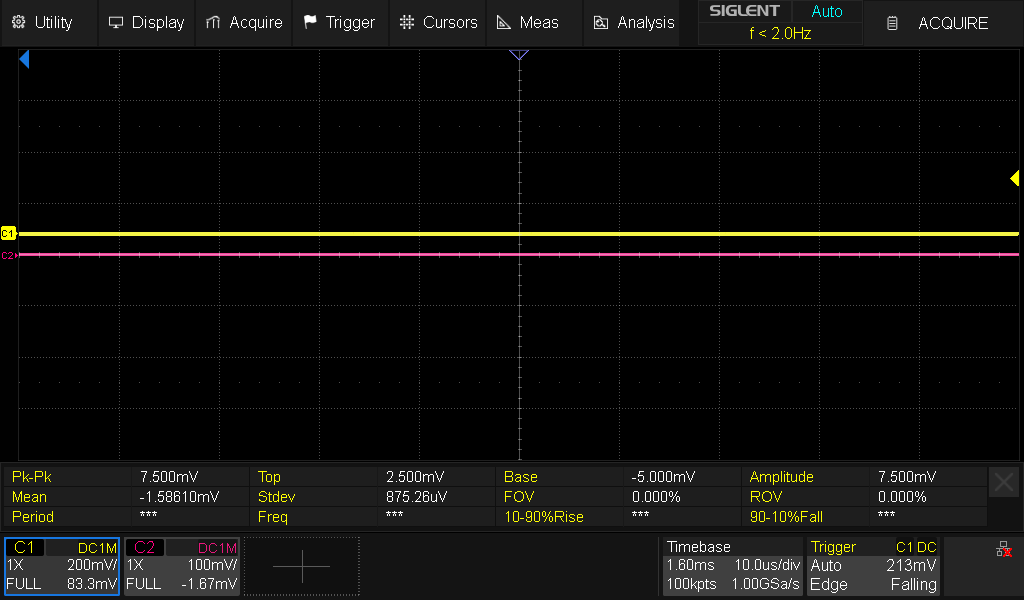

In [8]:
from IPython.display import Image
scope.write("PRIN? PNG")
data = scope.read_raw()
Image(data)

### Grabbing a trace

Let's try to parse the premble:

In [11]:
import time
import struct

# These are two parameters from the manual. But it says:
# "(Modify the following global variables according to the model)."
# I have no idea what the hell HORI_NUM is for the 814x 
# or if I have to change the tdiv_enum
# I guess I can reverse engineer it. 

HORI_NUM = 10
tdiv_enum = [200e-12,500e-12, 1e-9,\
 2e-9, 5e-9, 10e-9, 20e-9, 50e-9, 100e-9, 200e-9, 500e-9, \
 1e-6, 2e-6, 5e-6, 10e-6, 20e-6, 50e-6, 100e-6, 200e-6, 500e-6, \
 1e-3, 2e-3, 5e-3, 10e-3, 20e-3, 50e-3, 100e-3, 200e-3, 500e-3, \
 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
             
# Start by copy-pasting this from the manual
def parse_preamble(pre):
    WAVE_ARRAY_1 = pre[0x3c:0x3f + 1]
    wave_array_count = pre[0x74:0x77 + 1]
    first_point = pre[0x84:0x87 + 1]
    sp = pre[0x88:0x8b + 1]
    v_scale = pre[0x9c:0x9f + 1]
    v_offset = pre[0xa0:0xa3 + 1]
    interval = pre[0xb0:0xb3 + 1]
    code_per_div = pre[0xa4:0Xa7 + 1]
    adc_bit = pre[0xac:0Xad + 1]
    delay = pre[0xb4:0xbb + 1]
    tdiv = pre[0x144:0x145 + 1]
    probe = pre[0x148:0x14b + 1]

    ta_bytes = struct.unpack('i', WAVE_ARRAY_1)[0]
    point_num = struct.unpack('i', wave_array_count)[0]
    fp = struct.unpack('i', first_point)[0]
    sp = struct.unpack('i', sp)[0]
    interval = struct.unpack('f', interval)[0]
    delay = struct.unpack('d', delay)[0]
    tdiv_index = struct.unpack('h', tdiv)[0]
    probe = struct.unpack('f', probe)[0]
    vdiv = struct.unpack('f', v_scale)[0] * probe
    offset = struct.unpack('f', v_offset)[0] * probe
    code = struct.unpack('f', code_per_div)[0]
    adc_bit = struct.unpack('h', adc_bit)[0]
    tdiv = tdiv_enum[tdiv_index]
    for f in "vdiv, offset, interval, delay, tdiv, code, adc_bit".split(", "):
        print(f, "  ", "\t", eval(f))

In [12]:
scope.write("WAV:SOUR C1")
scope.write("WAV:PRE?")
pre = scope.read_raw()
print(pre)
parse_preamble(pre)

b'#9000000346WAVEDESC\x00\x00\x00\x00\x00\x00\x00\x00WAVEACE\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00Z\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00@x}\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00Siglent SDS\x00\x00\x00\x00\x00\xab\xcd\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00@x}\x01@x}\x01>x}\x01\x00\x00\x00\x00?x}\x01\x00\x00\x00\x00\x01\x00\x00\x00\xff\xff\xff\xff\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\xcd\xccL>\xab\xaa\xaa=\x00\x00\xf0E\x00\x00\x00\x00\x10\x00\xff\xff\x95\xbfV4-C\x1c\xeb\xe26Z?-C\x1c\xeb\xe26Z?V\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00S\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [ ]:
# The max trace length is 20 million points for the 814x, but the maximum transfer length is 5 million points.
# For traces longer than 5 million points, we need to do 
trace_points = int(float(scope.query(":ACQuire:POINts?")))
max_points_per_transfer = int(float(scope.query("WAV:MAXP?")))
n_transfers = int(np.ceil(trace_points / max_points_per_transfer))

In [ ]:
# The 814x has a 16 bit ADC
scope.write("WAV:WIDT WORD")

15

In [38]:
n_reads

4

In [15]:
pre

b'#9000000346WAVEDESC\x00\x00\x00\x00\x00\x00\x00\x00WAVEACE\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00Z\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xa0\x86\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00Siglent SDS\x00\x00\x00\x00\x00\xab\xcd\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xa0\x86\x01\x00\xa0\x86\x01\x00\x9e\x86\x01\x00\x00\x00\x00\x00\x9f\x86\x01\x00\x00\x00\x00\x00\x01\x00\x00\x00\xff\xff\xff\xff\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\xcd\xccL>\x00\x00\x00\x00\x00\x00\xf0E\x00\x00\x00\x00\x10\x00\xff\xff\x95\xbfV4-C\x1c\xeb\xe26Z?-C\x1c\xeb\xe26Z?V\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00S\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [31]:
float(scope.query(":ACQuire:POINts?"))/1e6

20.0

In [32]:
float(scope.query("WAV:MAXP?"))/1e6

5.0

In [25]:
scope.write("WAV:WIDT WORD")

15

In [19]:
help(scope.read_raw)

Help on method read_raw in module pyvisa.resources.messagebased:

read_raw(size: Optional[int] = None) -> bytes method of pyvisa.resources.usb.USBInstrument instance
    Read the unmodified string sent from the instrument to the computer.

    In contrast to read(), no termination characters are stripped.

    Parameters
    ----------
    size : Optional[int], optional
        The chunk size to use to perform the reading. Defaults to None,
        meaning the resource wide set value is set.

    Returns
    -------
    bytes
        Bytes read from the instrument.



## WFM Generator


https://siglentna.com/operating-tip/sdg-remote-scpi-command-to-request-a-screen-image/?pdf=23988

Not in programming manual...

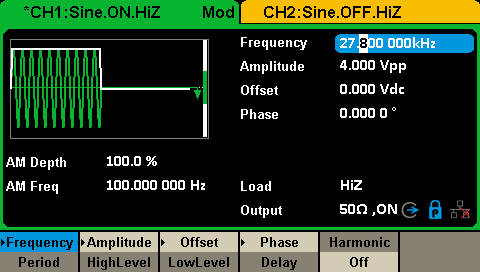

In [13]:
from IPython.display import Image
wfgen.write("SCDP")
data = wfgen.read_raw()
Image(data)

Cool!